In [1]:
import pandas as pd
import numpy as np
from scipy.stats import pearsonr, spearmanr
import sys
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression

In [65]:
# Define file paths for the "Actual Generation per Production Type" files

files = [
    'C:\\Users\\49176\\Task3\\Actual Generation per Production Type_201901010000-202001010000.csv',
    'C:\\Users\\49176\\Task3\\Actual Generation per Production Type_202001010000-202101010000.csv',
    'C:\\Users\\49176\\Task3\\Actual Generation per Production Type_202101010000-202201010000.csv',
    'C:\\Users\\49176\\Task3\\Actual Generation per Production Type_202201010000-202301010000.csv',
    'C:\\Users\\49176\\Task3\\Actual Generation per Production Type_202301010000-202401010000.csv',
    'C:\\Users\\49176\\Task3\\Actual Generation per Production Type_202401010000-202501010000.csv',
]


# CO₂-Emissionsfactors in (g/kWh)
emission_factors = {
    "Biomass - Actual Aggregated [MW]": 0.0,
    "Fossil Brown coal/Lignite - Actual Aggregated [MW]": 0.0,
    "Fossil Gas - Actual Aggregated [MW]": 390.43,
    "Fossil Hard coal - Actual Aggregated [MW]": 1044.87,
    "Solar - Actual Aggregated [MW]": 0.0,
    "Wind Onshore - Actual Aggregated [MW]": 0.0,
    "Nuclear - Actual Aggregated [MW]": 0.0,
    "Hydro Run-of-river and poundage - Actual Aggregated [MW]": 0.0,
    "Hydro Water Reservoir - Actual Aggregated [MW]": 0.0
}

# Load csv files with function through loop + delimiter
def load_and_combine(files):
    combined_data = []
    for file in files:
        df = pd.read_csv(file)
        df['DateTime'] = pd.to_datetime(df['MTU'].str.split(' - ').str[0], format="%d.%m.%Y %H:%M")
        combined_data.append(df)
    return pd.concat(combined_data, ignore_index=True)

actual_generation = load_and_combine(files)

# Filtern for columns
actual_generation = actual_generation[['DateTime', 'Biomass - Actual Aggregated [MW]',
                                       'Fossil Brown coal/Lignite - Actual Aggregated [MW]',
                                       'Fossil Gas - Actual Aggregated [MW]',
                                       'Fossil Hard coal - Actual Aggregated [MW]',
                                       'Solar - Actual Aggregated [MW]',
                                       'Wind Onshore - Actual Aggregated [MW]',
                                       'Nuclear - Actual Aggregated [MW]',
                                       'Hydro Run-of-river and poundage - Actual Aggregated [MW]',
                                       'Hydro Water Reservoir - Actual Aggregated [MW]']]

# check if columns are numeric
for col in actual_generation.columns[1:]:
    actual_generation[col] = pd.to_numeric(actual_generation[col], errors='coerce').fillna(0)

# vizualize the energy mix of yearly basis
actual_generation['Year'] = actual_generation['DateTime'].dt.year
actual_generation['Month'] = actual_generation['DateTime'].dt.to_period('M').astype(str)
actual_generation = actual_generation.drop(columns=['DateTime'])  # Entferne Datumsspalte, um Summenprobleme zu vermeiden
yearly_generation = actual_generation.groupby('Year').sum()


# calculate CO₂-Intensity
def calculate_co2_intensity(row):
    total_production = row.sum()
    co2_emissions = sum(row[col] * factor for col, factor in emission_factors.items())
    return co2_emissions / total_production if total_production > 0 else 0

actual_generation['CO2_Intensity'] = actual_generation[list(emission_factors.keys())].apply(calculate_co2_intensity, axis=1)





# Trends of proportion renewables, coal and gas
actual_generation['Renewables'] = (
    actual_generation['Biomass - Actual Aggregated [MW]'] +
    actual_generation['Solar - Actual Aggregated [MW]'] +
    actual_generation['Wind Onshore - Actual Aggregated [MW]'] +
    actual_generation['Hydro Run-of-river and poundage - Actual Aggregated [MW]'] +
    actual_generation['Hydro Water Reservoir - Actual Aggregated [MW]']
)

actual_generation['Coal'] = (
    actual_generation['Fossil Brown coal/Lignite - Actual Aggregated [MW]'] +
    actual_generation['Fossil Hard coal - Actual Aggregated [MW]']
)

actual_generation['Gas'] = actual_generation['Fossil Gas - Actual Aggregated [MW]']

# take numeric columns for each proportion yearly
numeric_columns = actual_generation.select_dtypes(include=['number']).columns
yearly_shares = actual_generation.groupby('Year')[['Renewables', 'Coal', 'Gas']].sum()
yearly_totals = actual_generation.groupby('Year')[numeric_columns].sum().sum(axis=1)
yearly_shares = yearly_shares.div(yearly_totals, axis=0) * 100



# proportion for renewables, coal and gas monthly
monthly_shares = actual_generation.groupby('Month')[['Renewables', 'Coal', 'Gas']].sum()
monthly_totals = actual_generation.groupby('Month')[numeric_columns].sum().sum(axis=1)
monthly_shares = monthly_shares.div(monthly_totals, axis=0) * 100









C:\Users\49176\AppData\Local\Temp\ipykernel_9572\763532005.py:30: DtypeWarning: Columns (2,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(file)


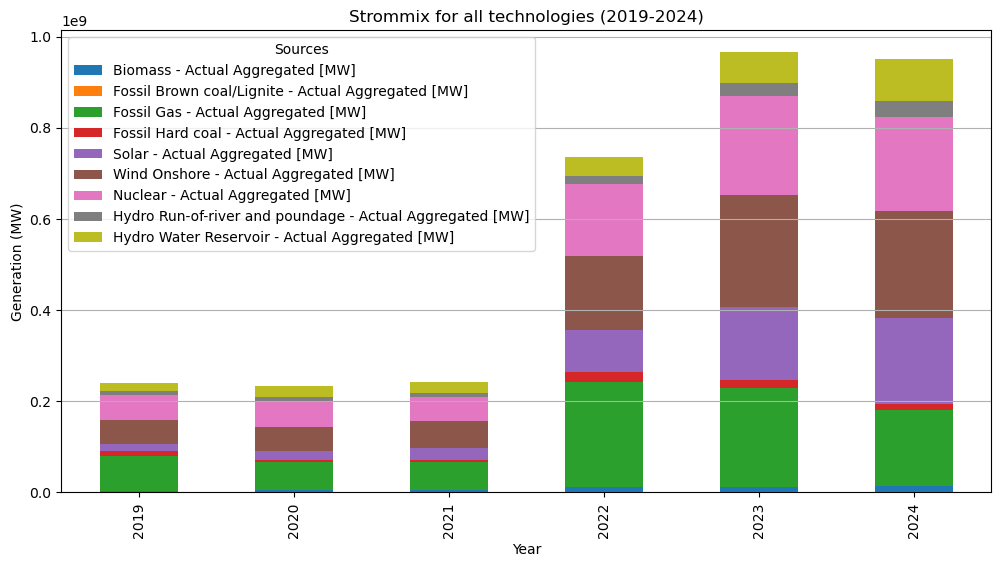

In [48]:
# Plot energy mix yearly 2019-2024
yearly_generation.plot(kind='bar', stacked=True, figsize=(12, 6))
plt.title('energy mix for all technologies (2019-2024)')
plt.xlabel('Year')
plt.ylabel('Generation (MW)')
plt.legend(title='Sources')
plt.grid(axis='y')
plt.show()

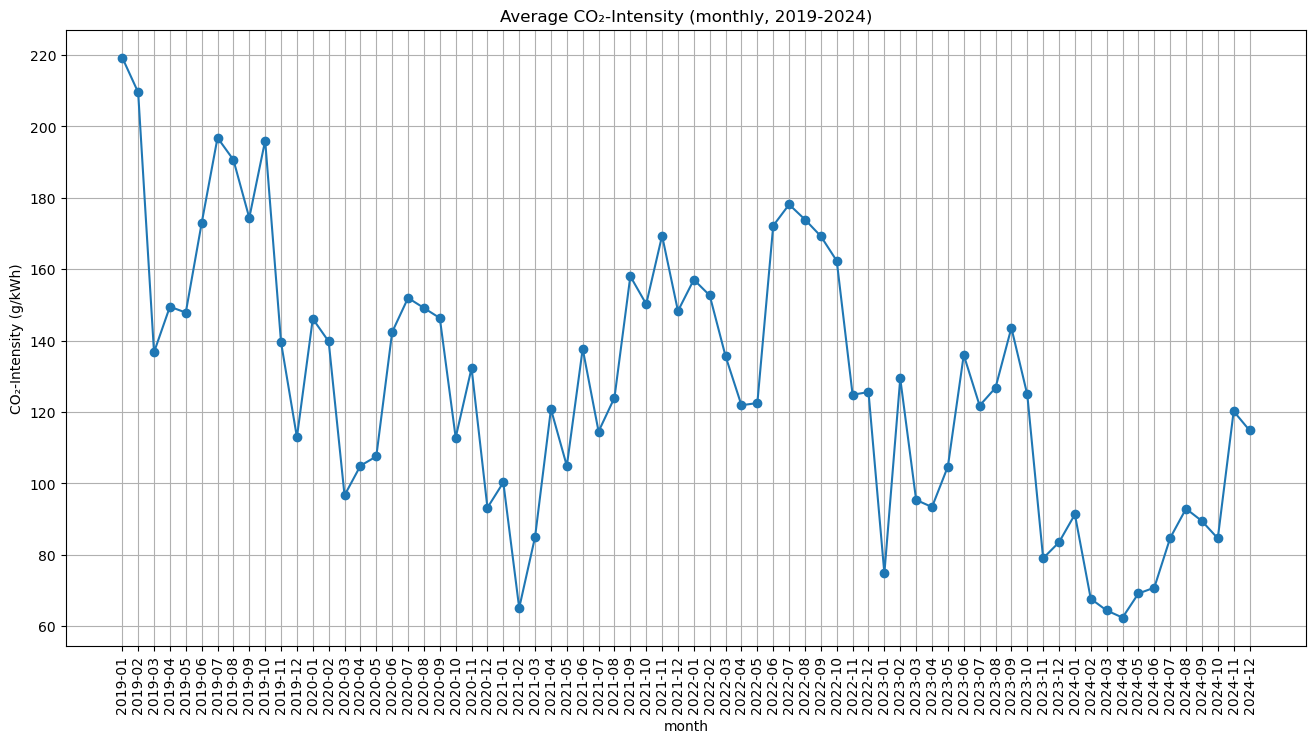

In [66]:
#plot  monthly CO₂-Intensity
monthly_co2_intensity = actual_generation.groupby('Month')['CO2_Intensity'].mean()
plt.figure(figsize=(16, 8))
plt.plot(monthly_co2_intensity.index, monthly_co2_intensity.values, marker='o')
plt.title('Average CO₂-Intensity (monthly, 2019-2024)')
plt.xlabel('month')
plt.ylabel('CO₂-Intensity (g/kWh)')
plt.xticks(rotation=90)
plt.grid()
plt.show()

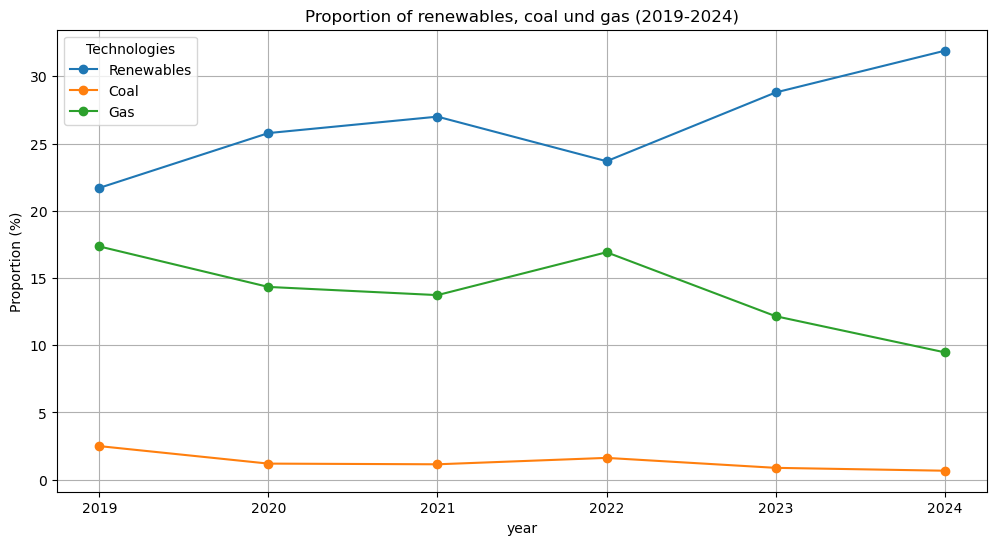

In [50]:
yearly_shares.plot(kind='line', marker='o', figsize=(12, 6))
plt.title('Proportion of renewables, coal und gas (2019-2024)')
plt.xlabel('year')
plt.ylabel('Proportion (%)')
plt.legend(title='Technologies')
plt.grid()
plt.show()

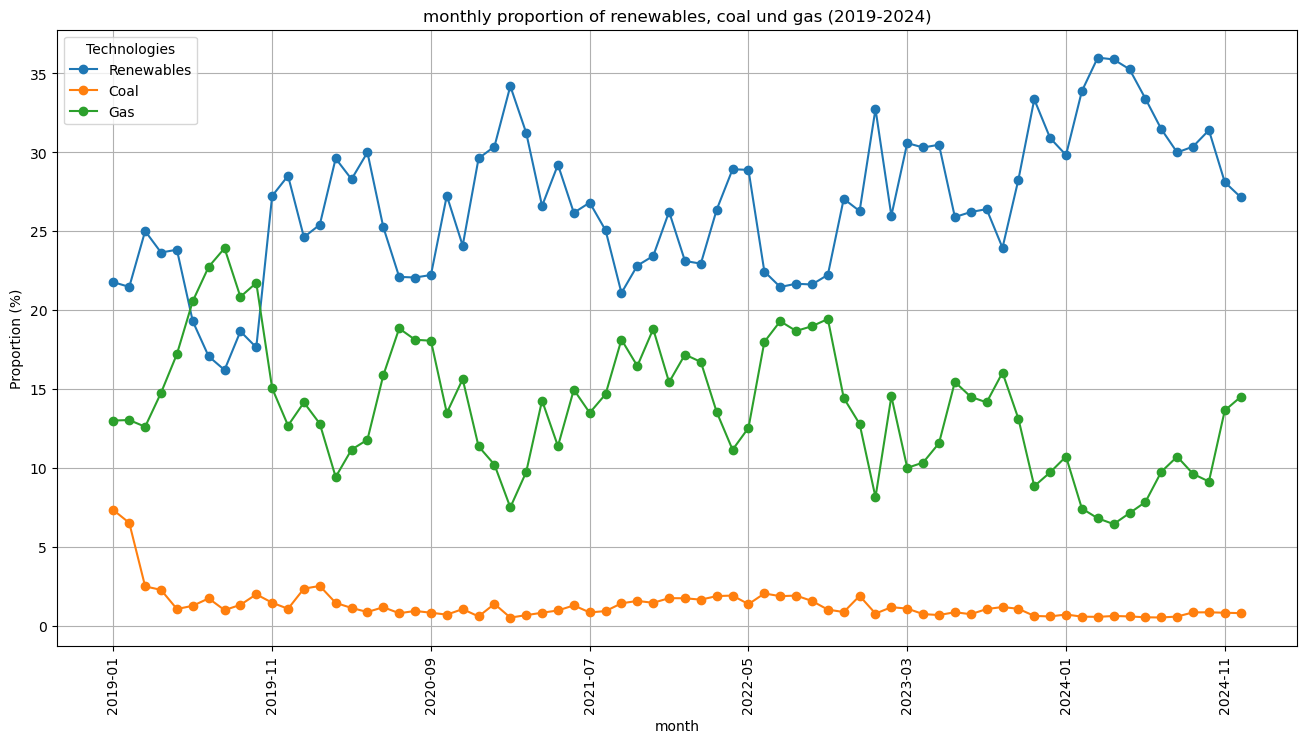

In [51]:
monthly_shares.plot(kind='line', marker='o', figsize=(16, 8))
plt.title('monthly proportion of renewables, coal und gas (2019-2024)')
plt.xlabel('month')
plt.ylabel('Proportion (%)')
plt.legend(title='Technologies')
plt.xticks(rotation=90)
plt.grid()
plt.show()

In [67]:
#preperation of timestamps
yearly_shares = yearly_shares.reset_index()  # check if years are available
yearly_shares['Timestamp'] = yearly_shares['Year'].astype(float)

co2_data = actual_generation.groupby('Year')['CO2_Intensity'].mean().reset_index()
co2_data['Timestamp'] = co2_data['Year'].astype(float)

In [55]:
# Function for regression
def perform_regression(df, feature):
    X = df[['Timestamp']].values  # Zeit als unabhängige Variable
    y = df[feature].values        # Abhängige Variable
    model = LinearRegression()
    model.fit(X, y)
    return model
# Function for prediction
def predict_year(model, target_value):
    return (target_value - model.intercept_) / model.coef_[0]

In [56]:
# lin. regression for each type
renewables_model = perform_regression(yearly_shares, 'Renewables')
gas_model = perform_regression(yearly_shares, 'Gas')
coal_model = perform_regression(yearly_shares, 'Coal')
co2_model = perform_regression(co2_data, 'CO2_Intensity')

In [57]:
# Values for defined thresholds
renewables_target = 85.0
gas_target = 10.0
coal_target = 0.0
co2_target = 0.0

In [58]:
#prediction 
year_renewables = predict_year(renewables_model, renewables_target)
year_gas = predict_year(gas_model, gas_target)
year_coal = predict_year(coal_model, coal_target)
year_co2 = predict_year(co2_model, co2_target)

In [69]:
print("Predicted years:")
print(f"renewable energies > 85%: {year_renewables:.2f}")
print(f"gas < 10%: {year_gas:.2f}")
print(f"coal-fired power plants phased out: {year_coal:.2f}")
print(f"Netto CO2-neutral: {year_co2:.2f}")


Predicted years:
renewable energies > 85%: 2057.59
gas < 10%: 2024.77
coal-fired power plants phased out: 2026.36
Netto CO2-neutral: 2031.43


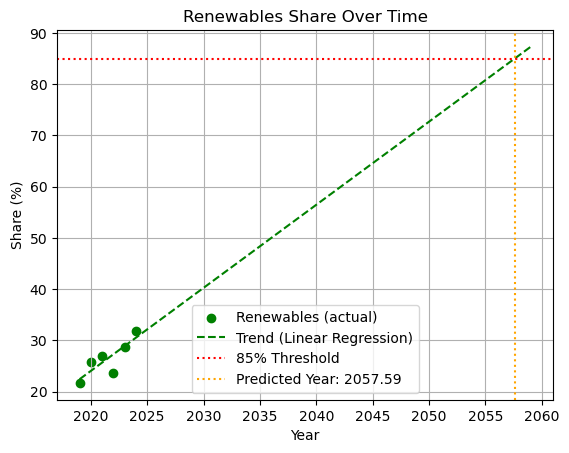

In [70]:
extended_years = np.arange(yearly_shares['Year'].min(), 2060)  # trend til 2060
extended_timestamps = extended_years.astype(float).reshape(-1, 1)  # timestamps for regression

# Vizualize the prediction
#plt.figure(figsize=(8, 6))

# Plot renewables
plt.scatter(yearly_shares['Year'], yearly_shares['Renewables'], label='Renewables (actual)', color='green')
plt.plot(extended_years, renewables_model.predict(extended_timestamps), label='Trend (Linear Regression)', color='green', linestyle='--')
plt.axhline(85, color='red', linestyle=':', label='85% Threshold')
plt.axvline(year_renewables, color='orange', linestyle=':', label=f'Predicted Year: {year_renewables:.2f}')
plt.title('Renewables Share Over Time')
plt.xlabel('Year')
plt.ylabel('Share (%)')
plt.legend()
plt.grid()

plt.show()

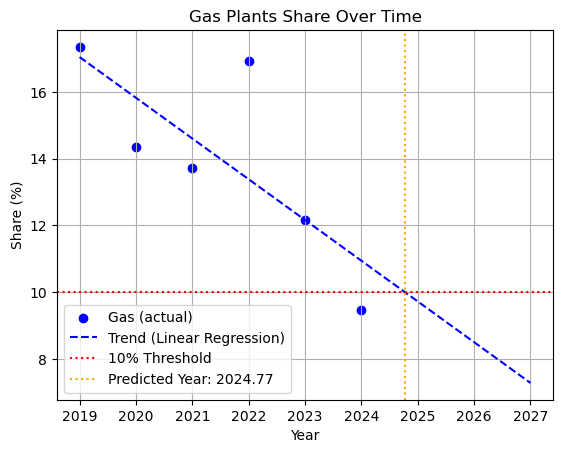

In [62]:
#plot gas plants
extended_years = np.arange(yearly_shares['Year'].min(), 2028)
extended_timestamps = extended_years.astype(float).reshape(-1, 1)

plt.scatter(yearly_shares['Year'], yearly_shares['Gas'], label='Gas (actual)', color='blue')
plt.plot(extended_years, gas_model.predict(extended_timestamps), label='Trend (Linear Regression)', color='blue', linestyle='--')
plt.axhline(10, color='red', linestyle=':', label='10% Threshold')
plt.axvline(year_gas, color='orange', linestyle=':', label=f'Predicted Year: {year_gas:.2f}')
plt.title('Gas Plants Share Over Time')
plt.xlabel('Year')
plt.ylabel('Share (%)')
plt.legend()
plt.grid()

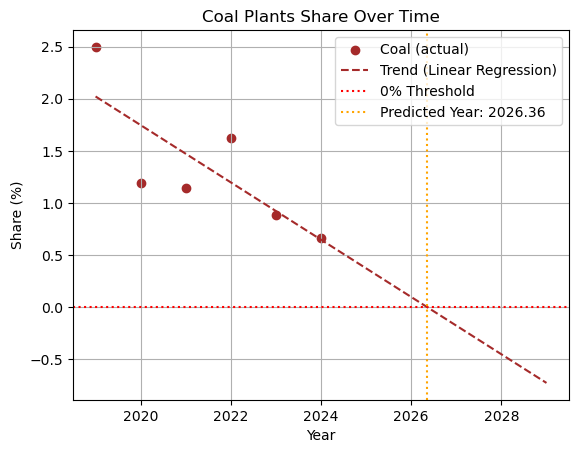

In [63]:
# coal-fired power plants
extended_years = np.arange(yearly_shares['Year'].min(), 2030)
extended_timestamps = extended_years.astype(float).reshape(-1, 1)

plt.scatter(yearly_shares['Year'], yearly_shares['Coal'], label='Coal (actual)', color='brown')
plt.plot(extended_years, coal_model.predict(extended_timestamps), label='Trend (Linear Regression)', color='brown', linestyle='--')
plt.axhline(0, color='red', linestyle=':', label='0% Threshold')
plt.axvline(year_coal, color='orange', linestyle=':', label=f'Predicted Year: {year_coal:.2f}')
plt.title('Coal Plants Share Over Time')
plt.xlabel('Year')
plt.ylabel('Share (%)')
plt.legend()
plt.grid()

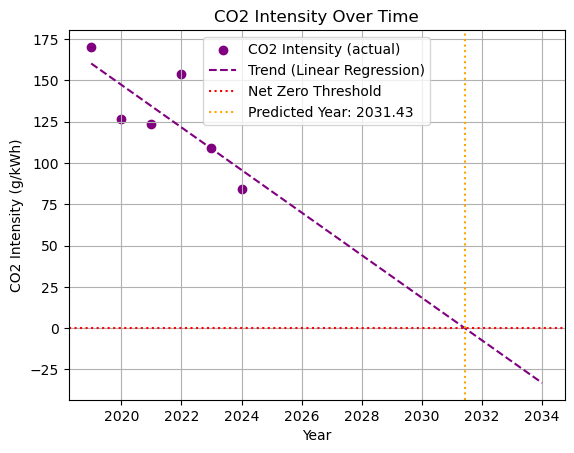

In [64]:
# CO2-Intensity for neutral electricity
co2_data = actual_generation.groupby('Year')['CO2_Intensity'].mean().reset_index()
co2_data['Timestamp'] = co2_data['Year'].astype(float)

extended_years = np.arange(co2_data['Year'].min(), 2035)
extended_timestamps = extended_years.astype(float).reshape(-1, 1)

plt.scatter(co2_data['Year'], co2_data['CO2_Intensity'], label='CO2 Intensity (actual)', color='purple')
plt.plot(extended_years, co2_model.predict(extended_timestamps), label='Trend (Linear Regression)', color='purple', linestyle='--')
plt.axhline(0, color='red', linestyle=':', label='Net Zero Threshold')
plt.axvline(year_co2, color='orange', linestyle=':', label=f'Predicted Year: {year_co2:.2f}')
plt.title('CO2 Intensity Over Time')
plt.xlabel('Year')
plt.ylabel('CO2 Intensity (g/kWh)')
plt.legend()
plt.grid()

#plt.tight_layout()
plt.show()